<a href="https://colab.research.google.com/github/leospalla/progetto/blob/main/DL_exercise_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Applied Deep Learning 2026 - "Exercise 0" - Introduction to Colab and some useful python skills

The excercises in this seminar are designed to work well in the Google Colab environments. You are free to run them on your local computer or another platform of your choice of course.

As first step in *every* exercise, create a copy of every notebook for yourself with "File -> Save a copy in Drive".

When you execute the first code cell in the notebooks of the exercises, Colab will ask you, whether this is safe. You can happily click "Run anyway" because you trust your lecturers of course ;)

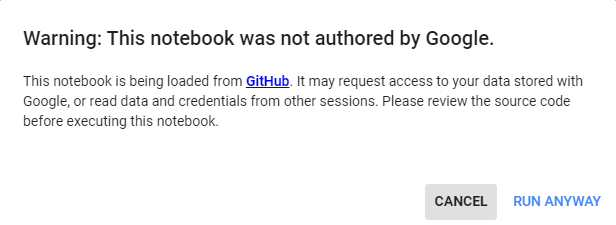

Google Colab essentiall works exactly like a Jupyter Notebook, which probably some of you are already familiar with. You can write and execute Python code interactively in every cell. The results are kept in memory until you restart the environment. Many Python packages like `numpy` or `scipy` are already preinstalled:

In [1]:
import numpy as np

x = np.linspace(0, 2*np.pi, 100) # create 100 linearly spaced numbers from 0 to 2*pi
y = np.sin(x) # compute the sine of those values

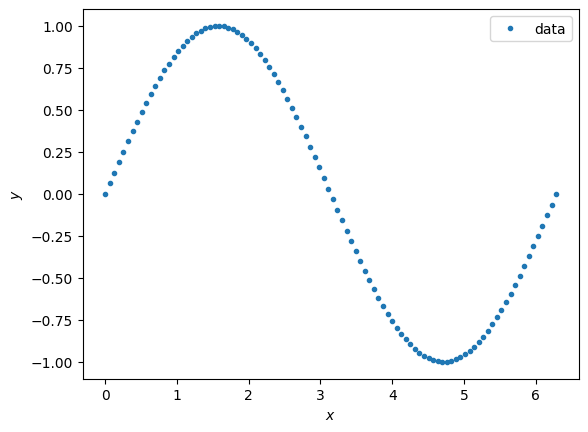

In [2]:
import matplotlib.pyplot as plt

plt.plot(x, y, '.', label='data')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend(loc='best'); # remove the `;` to see what changes
# you do not need to execute plt.show() in notebooks, the plot should appear anyway.

### Excersice 0: Hints
If you put the cursor inside of the brackets of a function, what happens if you hit `Shift+Tab` and then type anything (like a space or comma)? What about `Ctrl + Space`?

In [3]:
print()

# Python packages used throughout the course

The most important Python packages, besides the machine learning libraries we will use ([`scikit-learn`](https://scikit-learn.org/stable/) and [`tensorflow`/`keras`](https://www.tensorflow.org/api_docs)), are certainly [`numpy`](https://numpy.org/doc/stable/contents.html), [`matplotlib`](https://matplotlib.org/stable/index.html) and [`pandas`](https://pandas.pydata.org/docs/index.html). Additionally, [`seaborn`](https://seaborn.pydata.org/) is a very use- and powerful visualization library.

# <a href=https://numpy.org><img src="https://numpy.org/images/logo.svg" width=50 align=center>numpy</a> refresher
If you do not already know, you will learn that the world of machine learning is full of vectors and matrices. In Python, `numpy` is the tool of choice to handle those.


In [4]:
vec = np.array([1,2,3,4,5,6])
print(vec)

[1 2 3 4 5 6]


In [5]:
print('Shape of vec:', vec.shape)
print('Size of vec:', vec.size)
print('Dimension of vec:', vec.ndim)

Shape of vec: (6,)
Size of vec: 6
Dimension of vec: 1


In machine learning frameworks it is common, that both the design matrix `X` (the data we want to use for trainig) and the target vector `y` (the labels or whatever we want to predict as goal of the training) are expected in the form `SxF` (S,F) where `S` are the samples and `F` are the features.

In many cases, especially the target `y` has the shape like the vector we just created `(S,)`, in our case `(6,)`. This means, as you can see from the output of `vec.ndim`, that the vector is one-dimensional. There are two commonly used ways to change this to match the expected form for machine learning libraries:

In [6]:
# reshape the existing vector into a SxF matrix
y = vec.reshape(6, 1)
print('y:', y)
print('Shape of y:', y.shape)
print('Size of y:', y.size)
print('Dimension of y:', y.ndim)

y: [[1]
 [2]
 [3]
 [4]
 [5]
 [6]]
Shape of y: (6, 1)
Size of y: 6
Dimension of y: 2


In [7]:
# create a new dimension to transform the vector into a matrix
y = vec[:, np.newaxis]
print('y:', y)
print('Shape of y:', y.shape)
print('Size of y:', y.size)
print('Dimension of y:', y.ndim)

y: [[1]
 [2]
 [3]
 [4]
 [5]
 [6]]
Shape of y: (6, 1)
Size of y: 6
Dimension of y: 2


### Exercise 1: Row or column vector?

A common task in the background for machine learning are vector and matrix multiplications. Inspect the following commands. Which ones work, which ones give errors? If there is an error, why does it occur? If it works, what do they compute? What is a row vector, what a column vector in numpy? And what is the difference between those two anyway?

- `a = vec.reshape(-1, 1)`
- `b = vec.reshape(1, -1)`
- `c = vec.reshape(2, 3)`
- `d = vec.reshape(-1, 3)`
- `d = vec.reshape(-1, -1)`
- `e = vec[..., np.newaxis]`
- `f = c[:, np.newaxis]`
- `g = c[np.newaxis, :, :]`
- `h = c[np.newaxis, ...]`
- `i = np.dot(vec, vec)`
- `j = vec @ vec`
- `k = vec.T`
- `l = a.T`
- `m = np.dot(a, vec)`
- `n = c @ d`
- `o = c.T @ d`
- `p = c @ d.T`
- `q = c @ d.T @ c`
-` r = np.dot(c, d.T)`
- `s = np.matmul(c, d.T)`
- `t = np.dot(c, 4)`
- `u = np.dot(4, c)`
- `v = 4*c`


In [8]:
# space for a solution
a = vec.reshape(-1, 1)
print(a)
print(a.shape)
#so reshape(-1,1) basically turns the array into a column vector


[[1]
 [2]
 [3]
 [4]
 [5]
 [6]]
(6, 1)


In [9]:
b = vec.reshape(1, -1)
print(b)
print(vec)
print(b.shape)
print(vec.shape)
print(b.ndim)
print(vec.ndim)

# so rhesape(1,-1) adds an extra empty dimension to go from a 1D array to a 2D row vector, compatible with machine learning libraries

[[1 2 3 4 5 6]]
[1 2 3 4 5 6]
(1, 6)
(6,)
2
1


In [10]:
c = vec.reshape(2, 3)
print(c)
print(c.ndim)

#this one turns the array into a 2x3 2D matrix

[[1 2 3]
 [4 5 6]]
2


In [11]:
d = vec.reshape(-1, 3)
print(d)

# this one in this case, does the same as reshape(2,3) but it means to create a matrix with 3 columns, and the -1 means to automatically
# fill the rows with the array's values


[[1 2 3]
 [4 5 6]]


In [13]:
d = vec.reshape(-1, -1)

# this gives an error because it cannot automatically fill both rows and columns, you need to at least tell him how many rows you want,
# or how many columns (only one unknown dimension is allowed)


ValueError: can only specify one unknown dimension

In [14]:
e = vec[..., np.newaxis]
print(e)
print(e.shape)
print(e.ndim)
#this adds an empty dimension to transform the array into a matrix


[[1]
 [2]
 [3]
 [4]
 [5]
 [6]]
(6, 1)
2


In [15]:
f = c[:, np.newaxis]
print(f)
print(f.shape)
print(f.ndim)

#since c is already a 2D matrix, here we are adding a new empty dimension in the middle, to have a 3D tensor-like object


[[[1 2 3]]

 [[4 5 6]]]
(2, 1, 3)
3


In [16]:
g = c[np.newaxis, :, :]
print(g)
print(g.shape)
print(g.ndim)

 #here we are doing the same, but the new dimension is at the beginning


[[[1 2 3]
  [4 5 6]]]
(1, 2, 3)
3


In [17]:
h = c[np.newaxis, ...]
print(h)
print(h.shape)
print(h.ndim)

#here we are doing the same as before, but taking all the other dimensions as they are with "..."


[[[1 2 3]
  [4 5 6]]]
(1, 2, 3)
3


In [18]:
i = np.dot(vec, vec)
print(i)
#this computes the dot product between the vec vector and itself


91


In [19]:
j = vec @ vec
print(j)
#this is the same as before, it does the dot product but in a more concise way

91


In [20]:
k = vec.T
print(k)
print(vec)
#this one transposes the array, but since it's a one dimensional array, it doesn't actually change anything

[1 2 3 4 5 6]
[1 2 3 4 5 6]


In [21]:
l = a.T
print(l)

#now this actually transposes the object because it was a 2D matrix


[[1 2 3 4 5 6]]


In [22]:
m = np.dot(a, vec)

#this tries to compute the dot product but it fails because their dimension is not compatible

ValueError: shapes (6,1) and (6,) not aligned: 1 (dim 1) != 6 (dim 0)

In [23]:
n = c @ d

#same thing here, but now we are doing a matrix product. it cannot happen because of the incompatibily of the dimensions

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)

In [24]:
o = c.T @ d
print(o)

#now this works because c.T has shape (3,2) and d has shape (2,3), so we get a 3x3 matrix doing the matrix product

[[17 22 27]
 [22 29 36]
 [27 36 45]]


In [25]:
p = c @ d.T
print(p)

#same thing as before but now we obtain a 2x2 matrix because d.T has shape (3,2)

[[14 32]
 [32 77]]


In [26]:
q = c @ d.T @ c - r = np.dot(c, d.T)
print(q)

#this does not work because we are using twice the assignment operator "="

SyntaxError: cannot assign to expression (4058427747.py, line 1)

In [27]:
s = np.matmul(c, d.T)
print(s)

#this does the same as @, it computes the matrix multiplication

[[14 32]
 [32 77]]


In [28]:
t = np.dot(c, 4)
print(t)

#this multiplies the c matrix by a scalar


[[ 4  8 12]
 [16 20 24]]


In [29]:
u = np.dot(4, c)
print(u)

#this does the same as before because the scalar product is symmetrical

[[ 4  8 12]
 [16 20 24]]


In [30]:
v = 4*c
print(v)

#this does the same as before but in a more concise way


[[ 4  8 12]
 [16 20 24]]


So, a row vector in numpy has shape (1, n), so it's a matrix with n columns and just one row. The column vector has shape (n, 1), so it's a matrix with one column and n rows. Their difference is only on their shape basically.

## Excercise 2: Creating arrays

There are many ways to create arrays in numpy. Find out what the following do, what arguments they take and create some arrays with them:
- `np.zeros( ... )`
- `np.zeros_like( ... )`
- `np.ones( ... )`
- `np.ones_like( ... )`
- `np.eye( ... )`
- `np.linspace( ... )`
- `np.logspace( ... )`
- `np.arange( ... )`

In [31]:
v1 = np.zeros(5) #this creates an array of all zeros
print(v1)
print("---------------")


v2 = np.zeros_like(c) #this creates an array/matrix of all zeros with the same shape as the array/matrix passed to it
print(v2)
print("---------------")


v3 = np.ones((2,3)) #this creates an array/matrix of all ones
print(v3)
print("---------------")

v4 = np.ones_like(a) #this creates an array/matrix of all ones with the same shape as the array/matrix passed to it
print(v4)
print("---------------")

v5 = np.eye(4)  #this creates an 4 by 4 identity matrix (diagonal  with only ones as eigenvalues)
print(v5)
print("---------------")

v6 = np.linspace(0,10,5) #this one creates an array of 5 numbers evenly spaced between 0 and 10
print(v6)
print("---------------")

v7 = np.logspace(0,10,5) #this one creates an array of 5 numbers evenly spaced on a logarithmic scale between 10^0 and 10^10
print(v7)
print("---------------")

v8 = np.arange(0,10,2) #this one creates an array with elements from 0 to 10 (excluded) with a step of 2
print(v8)
print("---------------")

[0. 0. 0. 0. 0.]
---------------
[[0 0 0]
 [0 0 0]]
---------------
[[1. 1. 1.]
 [1. 1. 1.]]
---------------
[[1]
 [1]
 [1]
 [1]
 [1]
 [1]]
---------------
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
---------------
[ 0.   2.5  5.   7.5 10. ]
---------------
[1.00000000e+00 3.16227766e+02 1.00000000e+05 3.16227766e+07
 1.00000000e+10]
---------------
[0 2 4 6 8]
---------------


## Exercise 3: Indexing and masking

You will in many cases not want to use all values from an array/vector/matrix. To select only some of them, you need to find a way to adress only those values.
1. Create a matrix using the command `mat = np.arange(105).reshape(3, 5, 7)`. Describe the result. How many dimensions does it have, what is its shape, what is its minimum and maximum value.
2. Run the following commands and inspect the results. What do the commands do, how do they work? If there are errors, why do they occur? It can be helpful to display the matrix `mat` as well to see what's going on:
  - `mat[2, 1, 6]`
  - `mat[:, 0, 0]`
  - `mat[:, 2, 4]`
  - `mat[:, 4, :]`
  - `mat[:, :, 7]`
  - `mat[..., 5]`
  - `mat[ mat > 25 ]`
  - `mat[ mat > 25 ].shape`
  - `mat[ (mat > 25) & (mat < 50) ]`
  - `mat[ (mat > 25) and (mat < 50) ]`
  - `mat[ (mat < 10) | (mat > 90) ]`
  - `np.where( mat > 100 )`
  - `np.where( mat < 50, 0, mat)`
  - `np.where( mat < 50, 0, 1)`
  - `mat [ mat < 50 ] = -1`
  - `mat [ np.where(mat < 50) ] = -1`



In [32]:
# space for solutions
mat = np.arange(105).reshape(3, 5, 7)
print(mat)

[[[  0   1   2   3   4   5   6]
  [  7   8   9  10  11  12  13]
  [ 14  15  16  17  18  19  20]
  [ 21  22  23  24  25  26  27]
  [ 28  29  30  31  32  33  34]]

 [[ 35  36  37  38  39  40  41]
  [ 42  43  44  45  46  47  48]
  [ 49  50  51  52  53  54  55]
  [ 56  57  58  59  60  61  62]
  [ 63  64  65  66  67  68  69]]

 [[ 70  71  72  73  74  75  76]
  [ 77  78  79  80  81  82  83]
  [ 84  85  86  87  88  89  90]
  [ 91  92  93  94  95  96  97]
  [ 98  99 100 101 102 103 104]]]


What we obtained here is a 3-dimensional tensor, with shape (3,5,7). This means that it has 5 rows, 7 columns, distributed on 3 different "levels" (the third dimension). It has elements from 0 (the minimum value) to 104 (the maximum value).

In [33]:
mat[2, 1, 6] #this selects the element on the third level, on the second row, and on the last column, so 83
mat[:, 0, 0] #this selects the elements on the first row and on the first column for each level as an array, so [0 35 70]
mat[:, 2, 4] #this selects the elements on the third row and on the fifth column for each level as an array, so [18 53 88]
mat[:, 4, :] #this selects the elements on the fifth row in each level and for each column as matrix
mat[:, :, 7] #this gives an error because there is no column with index 7 (no eighth column)
mat[..., 5] #this collapses the 3D tensor in a 2D matrix by taking only the elements on the fifth column and keeping the previous dimensions (so it's an object with shape (3,5))
mat[ mat > 25 ] #this selects only the elements greater than 25 and gives them as a 1D array
mat[ mat > 25 ].shape #this gives the shape of the 1D array (so basically its length)
mat[ (mat > 25) & (mat < 50) ] #this selects only the elements greater than 25 and smaller than 50 and gives them as a 1D array
mat[ (mat > 25) and (mat < 50) ] #this gives an error because the & compares the elements inside the arrays, while "and" tries to compare two arrays of booleans
mat[ (mat < 10) | (mat > 90) ] #this selects the elements greater than 90 or smaller than 10 and gives them as a 1D array
np.where( mat > 100 ) #this gives the indices of the elements inside the matrix greater than 100
np.where( mat < 50, 0, mat) #this acts as a if-else statement: if the element is smaller than 50, it gets replaced with 0, if not it stays the same
np.where( mat < 50, 0, 1) #this is like before: if the element is smaller than 50, it gets replaced with 0, if it's greater with 1
mat [ mat < 50 ] = -1  #this replaces all the elements smaller than 50 with -1
mat [ np.where(mat < 50) ] = -1 #this is the same as before

IndexError: index 7 is out of bounds for axis 2 with size 7

## Exercise 4: Random numbers and statistics

Numpy also has many functions for random number generation and statistics.
1. Look up the following functions and experiment with them to see how they work:
  - `np.random.uniform( ... )`
  - `np.random.normal( ... )`
  - `np.random.poisson( ... )`
  - `np.random.choice( ... )`
  - `np.random.shuffle( ... )`

2. More tasks with random numbers:
  - what is wrong with this: `a = np.random.shuffle(b)`
  - look up the function `plt.hist( ... )` and show histograms of a Gaussian and a normal distribution. What can you do with the parameters `range`, `bins`, `alpha`, `density`, `histtype`, `stacked`?
  - create a matrix `A` of shape (5, 4, 3, 2, 1) of Gaussian distributed values
  - what does `A.mean()` do? What does `A.mean(axis=(1,3,2))` do?
  - Does `A.std()` compute a sample or population standard deviation? What is the difference between them?
  - create another matrix `B = np.ones(shape=(6, 8, 10))`. Execute the following: `B_rebin = B.reshape(3, 2, 4, 2, 5, 2).mean(axis=(1, 3, 5))`. What is the result? What happend here? In what real situations would you use `mean` here, when `sum`?


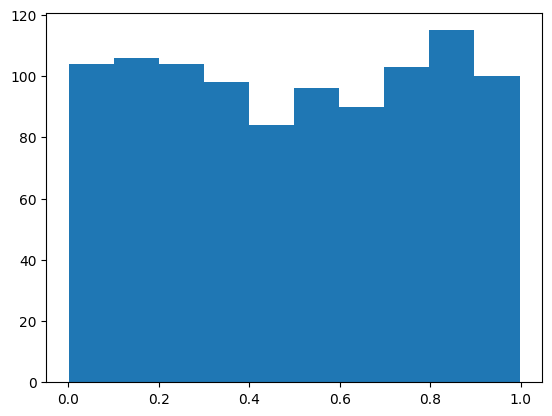

In [34]:
#1)
d1 = np.random.uniform(0,1,1000) #this generates 1000 points from an uniform distribution between 0 and 1
plt.hist(d1)
plt.show()


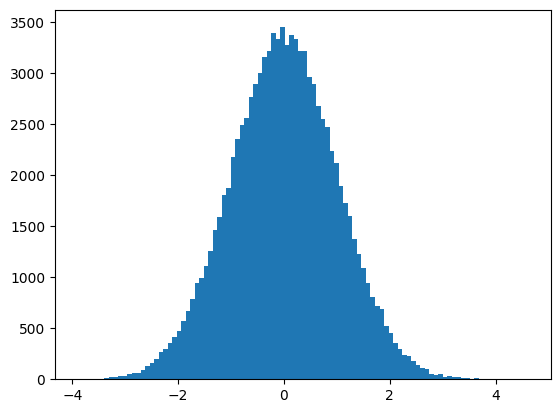

In [35]:
d2 = np.random.normal(0,1,100000) #this generates 1000 points from a normal distribution with mean 0 and variance 1
plt.hist(d2, bins = 100)
plt.show()

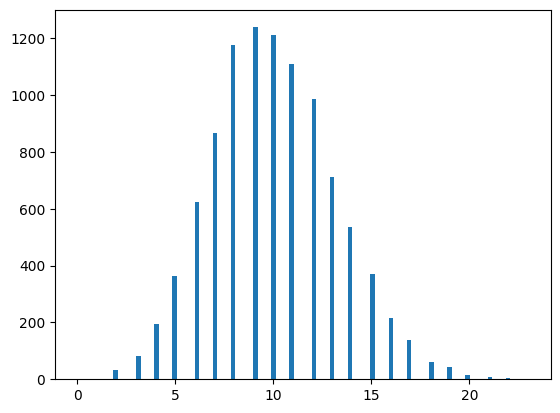

In [36]:
d3 = np.random.poisson(10,10000) #this generates 10000 points (integer numbers) from a poisson distribution with mean 10
plt.hist(d3, bins = 100)
plt.show()

In [37]:
nums = [1,2,3,4,5,6,7,8,9,10]
choice = np.random.choice(nums, 4) #this chooses 4 numbers from the list of numbers given to it
print(choice)

[6 5 4 9]


In [38]:
np.random.shuffle(nums) #this shuffles the list of numbers given to it
print(nums) #now they should be in a random order

[9, 1, 7, 10, 8, 5, 3, 4, 6, 2]


In [39]:
#2)
nums2 = np.random.shuffle(nums) #this doesn't work because the function np.random.shuffle shuffles the elements inside the array internally, but returns None
print(nums2)

None


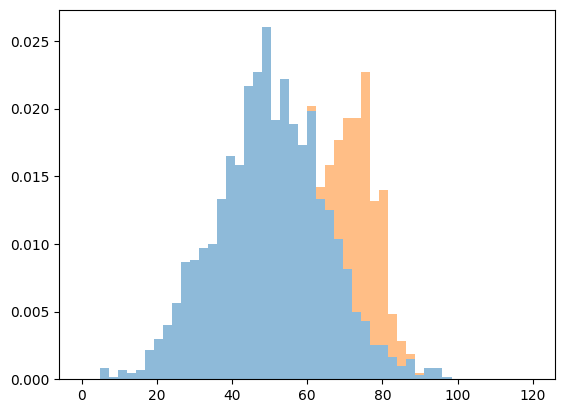

In [40]:
dA = np.random.normal(50, 15, 2000)
dB = np.random.normal(75, 5, 500)
plt.hist([dA, dB],
         bins=50,  #decides the number of bins
         range=(0, 120), #gives the limits on the x axis
         alpha=0.5, #transparency of the histogram
         density=True, #if True the histogram is normalized to 1
         histtype='stepfilled', #changes the graphic style of the histogram
         stacked=True, #puts the two distributions one over the other
          )
plt.show()

In [41]:
A = np.random.normal(0, 1, size=(5, 4, 3, 2, 1))
print(A.mean()) #this computes the mean of all values in the matrix
print(A.mean(axis=(1,3,2))) #this computes the mean collpasing only the indicated dimensions, so the second, the fourth and the third, thus remaining with a (5,1) matrix


-0.10580976097344409
[[-0.16722993]
 [ 0.09642627]
 [-0.31719901]
 [-0.46597501]
 [ 0.32492888]]


In [42]:
print(A.std()) #this computes a population standard deviation? Which means that it uses N at the denominator, meanwhile the sample uses N-1


0.9867993416773919


In [43]:
B = np.ones(shape=(6, 8, 10))
B_rebin = B.reshape(3, 2, 4, 2, 5, 2).mean(axis=(1, 3, 5))

print(B_rebin)

# here we created a matrix (6,8,10) full of ones, then we reshaped it
# by dividing every original dimension in two parts (6-> (3,2), 8-> (4,2), 10 -> (5,2))
# then we computed the mean onto the second, fourth and sixth axes, so that
# we end up with a (3,4,5) matrix


[[[1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]]

 [[1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]]

 [[1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]]]


## <a href=https://pandas.pydata.org/><img src=https://pandas.pydata.org/docs/_static/pandas.svg align=center width=150></a> Pandas refresher

From the [pandas documentation](https://pandas.pydata.org/docs/getting_started/index.html):

### What kind of data does pandas handle?
When working with tabular data, such as data stored in spreadsheets or databases, pandas is the right tool for you. pandas will help you to explore, clean and process your data. In pandas, a data table is called a DataFrame.

<img src=https://pandas.pydata.org/docs/_images/01_table_dataframe.svg align=center width=300>

The pandas documentation is *that* good, that rewriting it would be pointless.

### Exercise 5: 10 minutes to pandas

To get warm with pandas, you should work your way through [this excellent quick start](https://pandas.pydata.org/docs/user_guide/10min.html#min) before you answer the following questions:
- what is a DataFrame?
- what is a Series?
- How is a Series/ DataFrame different from numpy arrays?
- How do you get numpy arrays from DataFrames?
- What do you need `.loc( ... )` for?
- What does `groupby` do? Find a real-world scenario where this might be very useful. Can you think of a potential application in machine learning?
- There are preinstalled data samples on the virtual machines running this Colab notebook. Use pandas `read_csv` to load the file `"sample_data/california_housing_train.csv"`. What do you think does this dataset describe? Look it up on the internet.
  - How many entries does the table have? How many columns? Are there missing values?
  - what are the min, max, mean and std dev of each column?
  - Create a scatterplot of `median_house_value` against `median_income`
  - Create a new column containing `total_rooms/population`.


In [44]:
!ls sample_data

anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


In [45]:
import pandas as pd
# space for solutions


A data frame is a 2D data container, similar to a table or an excel file.
A series is a column of a data frame, so it's similar to a monodimensional array but it has an index associated to it. So a data frame can be sees as a container of multiple series, which share the same index.

These object are different from numpy arrays because they have an index associated to them, and can store data of different types. Also in dataframes we can name columns and rows with labels, which is an extra way to access elements that numpy arrays don't have (they only have the index of the element's position).

To get numpy arrays from a dataframe the standard function used is "to_numpy()", and it's used to convert pandas dataframs into 2D numpy arrays with only the values (no indices or labels), or a pandas series into a 1D array.

In [46]:
# to_numpy() example
df = pd.DataFrame({'Mass': [1.2, 3.4, 3.54, 122, 0.5953, 3423,], 'Energy': [5.5, 7.1, 4.3, 453, 0.795, 3544,]})
print(df)
print("-------------")

matrix = df.to_numpy()
print(matrix)

        Mass    Energy
0     1.2000     5.500
1     3.4000     7.100
2     3.5400     4.300
3   122.0000   453.000
4     0.5953     0.795
5  3423.0000  3544.000
-------------
[[1.200e+00 5.500e+00]
 [3.400e+00 7.100e+00]
 [3.540e+00 4.300e+00]
 [1.220e+02 4.530e+02]
 [5.953e-01 7.950e-01]
 [3.423e+03 3.544e+03]]


In [47]:
# .loc[] selects specific rows and columns by asking for their actual names (labels)

high_energy_particles = df.loc[df['Energy'] > 100]
print(high_energy_particles)




     Mass  Energy
3   122.0   453.0
5  3423.0  3544.0


In [48]:
# groupby does 3 things: it breaks the dataframe into smaller, separate tables based on a category,
# then it applies a mathematical function (like mean, sum, count, max) to each of those smaller tables,
# and at the end it combines the results back together into a brand new summary table. For example:

df['Particle_Type'] = ['Electron', 'Muon', 'Muon', 'Proton', 'Electron', 'Proton']
print(df)
print("-------------")

means = df.groupby('Particle_Type').mean()
print(means)

        Mass    Energy Particle_Type
0     1.2000     5.500      Electron
1     3.4000     7.100          Muon
2     3.5400     4.300          Muon
3   122.0000   453.000        Proton
4     0.5953     0.795      Electron
5  3423.0000  3544.000        Proton
-------------
                     Mass     Energy
Particle_Type                       
Electron          0.89765     3.1475
Muon              3.47000     5.7000
Proton         1772.50000  1998.5000


In [49]:
housing_data = pd.read_csv("sample_data/california_housing_train.csv")
print(housing_data)



       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -114.31     34.19                15.0       5612.0          1283.0   
1        -114.47     34.40                19.0       7650.0          1901.0   
2        -114.56     33.69                17.0        720.0           174.0   
3        -114.57     33.64                14.0       1501.0           337.0   
4        -114.57     33.57                20.0       1454.0           326.0   
...          ...       ...                 ...          ...             ...   
16995    -124.26     40.58                52.0       2217.0           394.0   
16996    -124.27     40.69                36.0       2349.0           528.0   
16997    -124.30     41.84                17.0       2677.0           531.0   
16998    -124.30     41.80                19.0       2672.0           552.0   
16999    -124.35     40.54                52.0       1820.0           300.0   

       population  households  median_income  media

In [50]:
housing_data.info() #this is to get additional informations and the null count

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [51]:
housing_data.describe() # this is to get the min, max, mean and dev std for each column



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


,rooms_per_person
0,5.529064
1,6.775908
2,2.162162
3,2.914563
4,2.330128
...,...
95,1.757642
96,2.041276
97,2.213911
98,1.761299


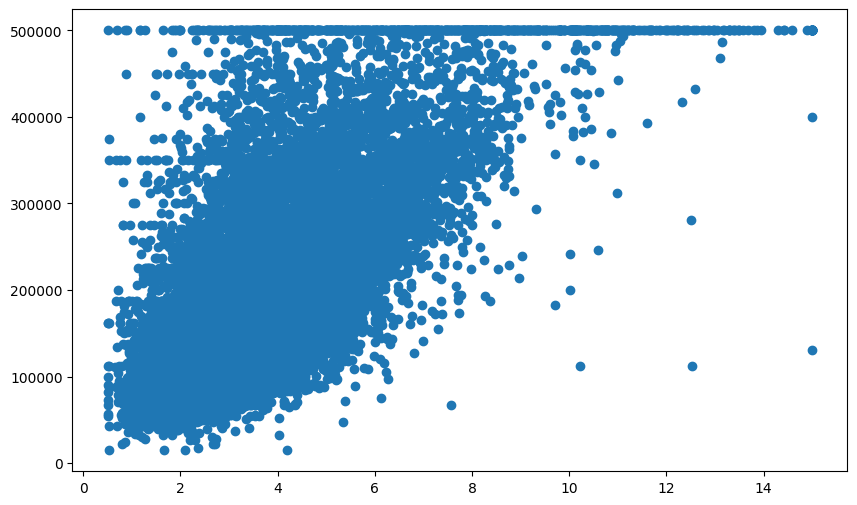

In [52]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(housing_data['median_income'], housing_data['median_house_value'])
housing_data['rooms_per_person'] = housing_data['total_rooms'] / housing_data['population']

housing_data["rooms_per_person"].head(100) #just to see some values


# <a href=https://seaborn.pydata.org/><img src=https://seaborn.pydata.org/_static/logo-wide-lightbg.svg width=200 align=center></a> Seaborn - just a word on it

Seaborn simply makes quite nice plots. You should check out [their documentation](https://seaborn.pydata.org/). This is one example plot:

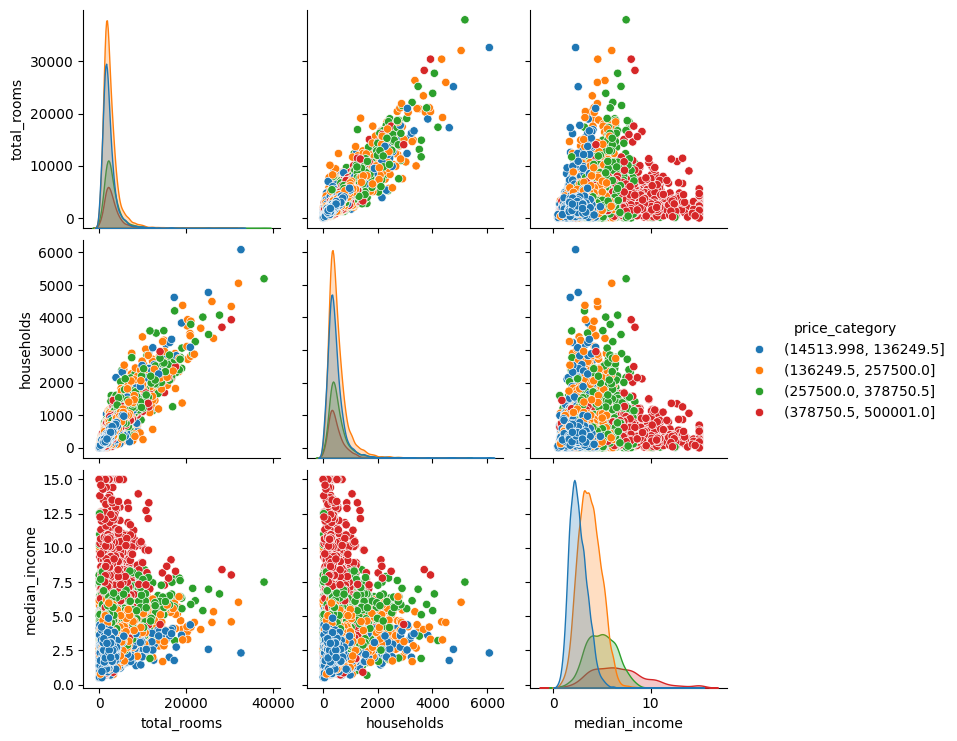

In [53]:
import seaborn as sns
# read the csv we used before
data = pd.read_csv("sample_data/california_housing_train.csv")
# we create a new category feature dividing the house value in 4 ranges
data["price_category"] = pd.cut(data["median_house_value"], 4)
# the actual plot
sns.pairplot(data, vars=["total_rooms", "households", "median_income"], hue="price_category")

# K-Nearest Neighbors

## Excercise 6: Perform a classification using K-nearest neighbors classifier discussed in the lecture.

http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

In [54]:
# we load the training data from the local virtual machine as well and get a numpy array from it
mnist_train = pd.read_csv("sample_data/mnist_train_small.csv", header=None ).to_numpy()
# the first entry is the digit, the rest of the array contains the pixel values
digits_train = mnist_train[:,0]
images_train = mnist_train[:,1:]
print(digits_train.shape)
print(images_train.shape)

(20000,)
(20000, 784)


This is a 6


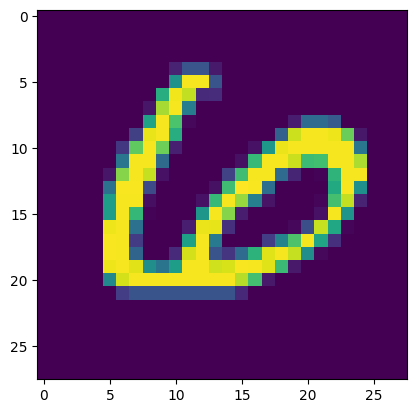

In [55]:
# the images are 28x28 but we will use the flattened array for training because KNN can only handle tabular data
plt.imshow(images_train[0].reshape(28,28));
print(f"This is a {digits_train[0]}")

In [56]:
# we train on some data and then we test on some other data, where would be the joke otherwise?
mnist_test = pd.read_csv("sample_data/mnist_test.csv", header=None ).to_numpy()
digits_test = mnist_test[:,0]
images_test = mnist_test[:,1:]

In [57]:
# import the classifier
from sklearn.neighbors import KNeighborsClassifier

# we use 7 next neighbors (this is rather much)
kn = KNeighborsClassifier(n_neighbors=7)

# for now, we will only use 100 training samples to keep the runtime low
N_samples = 100
X_train = images_train[:N_samples]
y_train = digits_train[:N_samples]
# this trains the KNN classifier. We pass the images and the digits as design matrix and target vector
kn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

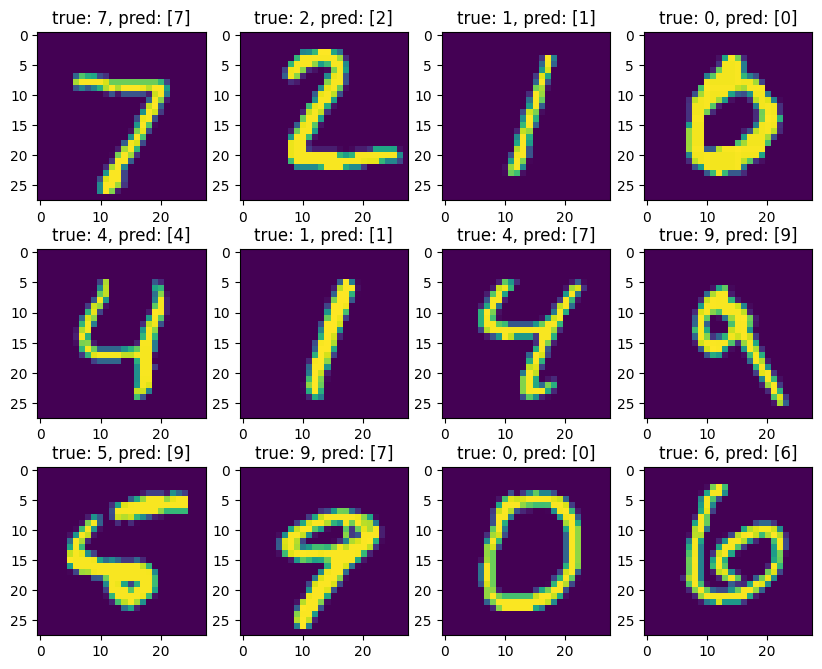

In [58]:
rows    = 3
columns = 4
f, axes = plt.subplots(rows, columns, figsize=(10,8))

idx = 0
for r in range(rows):
  for c in range(columns):
      img        = images_test[idx].reshape(1, -1) # the shape needs to be (1, features)
      digit_true = digits_test[idx]
      digit_pred = kn.predict(img)
      axes[r, c].imshow(img.reshape(28,28))
      axes[r, c].set_title(f"true: {digit_true}, pred: {digit_pred}")
      idx += 1

# Exercise 7 - The actual tasks:
- Predict the digits for the whole training and test data set
- Compute the accuracy for both training and test predictions. How much difference is there?
- Plot some examples of misclassified digits.
- How does the performance of the algorithm change with the number of nearest neighbours?

In [59]:
# space for solutions

y_train_pred = kn.predict(images_train)
y_test_pred = kn.predict(images_test)



In [60]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(digits_train, y_train_pred)
test_accuracy = accuracy_score(digits_test, y_test_pred)

print(f'Accuracy on Training Set: {train_accuracy * 100:.2f}%')
print(f'Accuracy on Test Set: {test_accuracy * 100:.2f}%')

Accuracy on Training Set: 64.78%
Accuracy on Test Set: 66.49%
